In [ ]:
import cv2
import numpy as np

# Image size
width, height = 900, 600
img = np.zeros((height, width, 3), dtype=np.uint8)

# -------------------------
# 1. Sunset gradient
# -------------------------
for y in range(height):
    t = y / height

    # Sky colors: blue -> purple -> orange
    if t < 0.65:
        r = int(40 + 180 * t / 0.65)
        g = int(80 - 40 * t / 0.65)
        b = int(180 - 100 * t / 0.65)
    else:
        r = int(220 - 80 * (t - 0.65) / 0.35)
        g = int(100 + 50 * (t - 0.65) / 0.35)
        b = int(70 + 30 * (t - 0.65) / 0.35)

    img[y, :] = (b, g, r)

# -------------------------
# 2. Sun
# -------------------------
cv2.circle(img, (680, 180), 70, (0, 220, 255), -1)
cv2.circle(img, (680, 180), 55, (50, 240, 255), -1)

# -------------------------
# 3. Mountains
# -------------------------
mountains = np.array([
    [0, 400],
    [140, 250],
    [250, 390],
    [390, 210],
    [520, 390],
    [650, 270],
    [800, 400],
    [900, 300],
    [900, 600],
    [0, 600]
])

cv2.fillPoly(img, [mountains], (45, 35, 70))

# Snow peaks
cv2.fillPoly(
    img,
    [np.array([[390, 210], [350, 270], [380, 250],
               [410, 270], [440, 260]])],
    (230, 230, 240)
)

# -------------------------
# 4. Lake
# -------------------------
cv2.rectangle(img, (0, 400), (900, 600), (90, 80, 100), -1)

# Sunset reflection
for i in range(15):
    y = 420 + i * 10
    half_width = int(90 - i * 4)

    cv2.line(
        img,
        (680 - half_width, y),
        (680 + half_width, y),
        (80, 140, 220),
        3
    )

# -------------------------
# 5. Foreground
# -------------------------
cv2.fillPoly(
    img,
    [np.array([
        [0, 520],
        [120, 470],
        [250, 530],
        [400, 490],
        [550, 540],
        [700, 480],
        [900, 530],
        [900, 600],
        [0, 600]
    ])],
    (20, 25, 30)
)

# -------------------------
# 6. Trees
# -------------------------
def tree(x, y, scale=1):
    color = (15, 25, 20)

    cv2.rectangle(
        img,
        (x - int(5 * scale), y),
        (x + int(5 * scale), y + int(70 * scale)),
        color,
        -1
    )

    for i, size in enumerate([45, 35, 25]):
        cy = y - int(i * 25 * scale)
        cv2.circle(img, (x, cy), int(size * scale), color, -1)

tree(100, 490, 1.2)
tree(180, 500, 0.8)
tree(800, 500, 1.3)
tree(850, 510, 0.9)

# -------------------------
# 7. Text
# -------------------------
cv2.putText(
    img,
    "OpenCV Test",
    (30, 60),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (255, 255, 255),
    3,
    cv2.LINE_AA
)

# -------------------------
# 8. Save and display
# -------------------------
cv2.imwrite("opencv_test.png", img)

cv2.imshow("Beautiful OpenCV Test", img)
cv2.waitKey(0)
cv2.destroyAllWindows()


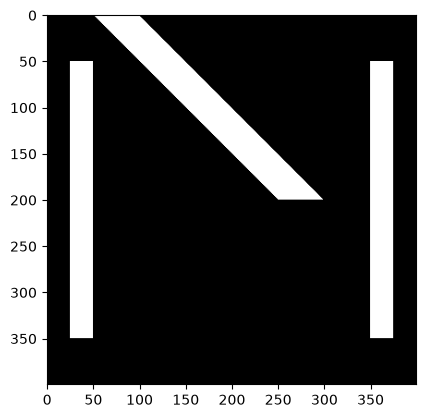

In [25]:
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((400, 400), dtype=np.uint8)

image[50:350, 25:50] = 255
image[50:350, 350:375] = 255

y,x=np.indices((400,400))
image[(x-y>50)&(x-y<100)&(y<200)]=255
plt.imshow(image, cmap="gray")
plt.axis("on")
plt.show()


Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814


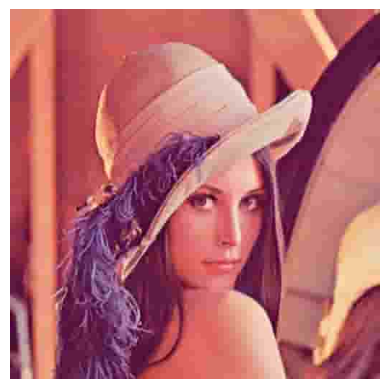

786432


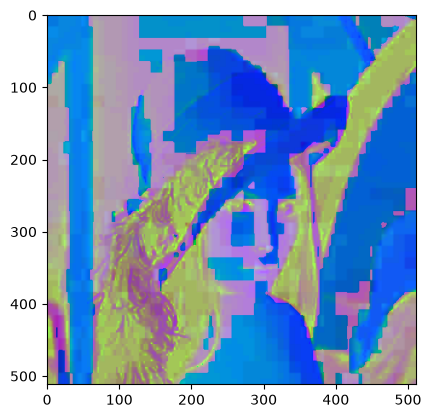

In [51]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#image = plt.imread("\\192.168.1.10\shear all\lena5.jpg")
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())

plt.imshow(image)
plt.axis("off")
plt.show()
print(image.nbytes)
import cv2
image = cv2.imread(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
plt.imshow(hsv)

